# Deep Learning-Based Energy Consumption Prediction
## Reimplementation of IEEE Published Paper (2025)
**Author:** Muhammad Umer Mujahid  
**Models:** Proposed Model 1 (Bi-LSTM) | Proposed Model 2 (CNN-BiLSTM)  
**Dataset:** Smart Home Dataset with Weather Information — Kaggle (2016)

## 1. Import Libraries

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

print("Python version:", torch.__version__)
print("Pandas version", pd.__version__)
print("All libraries loaded successfully.")


Python version: 2.12.1+cpu
Pandas version 3.0.3
All libraries loaded successfully.


## 2. Data Loading and Preprocessing
*Dataset: Smart Home Dataset with Weather Information (Kaggle, 2016)*  
*503,911 data points at 1-minute intervals → resampled to daily frequency*  
*Target variable: `use [kW]` — total home energy consumption*

In [2]:
# Load dataset
df = pd.read_csv('HomeC.csv', low_memory=False)
df = df[df['time'] != '\\'].copy()

#Keep only numeric rows in time column
df['use [kW]'] = pd.to_numeric(df['use [kW]'], errors='coerce')
df.index = pd.date_range(start='2016-01-01', periods=len(df), freq='min')
                        
# Select target column only
df_daily = df[['use [kW]']].dropna()

# Resample to daily frequency
df_daily = df[['use [kW]']].resample('D').mean()
df_daily.dropna(inplace=True)

print("Shape after resampling:", df_daily.shape)
print("\nFirst 5 rows:")
print(df_daily.head())
print("\nDate range:", df_daily.index[0], "to", df_daily.index[-1])
 


Shape after resampling: (350, 1)

First 5 rows:
            use [kW]
2016-01-01  1.257057
2016-01-02  1.278363
2016-01-03  1.091132
2016-01-04  1.200792
2016-01-05  0.940083

Date range: 2016-01-01 00:00:00 to 2016-12-15 00:00:00


## 3. Data Normalization
*Paper used MinMax scaling (0 to 1) to prevent activation function saturation in LSTM layers*

In [3]:
# MinMax normalization - same as paper
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df_daily)

print("Original data range:", df_daily['use [kW]'].min().round(4), "to", df_daily['use [kW]'].max().round(4))
print("Scaled data range:", data_scaled.min().round(4), "to", data_scaled.max().round(4))
print("Shape:", data_scaled.shape)

Original data range: 0.3011 to 3.7057
Scaled data range: 0.0 to 1.0
Shape: (350, 1)


## 4. Sequence Preparation
*Paper used time_step = 10 (10 previous days to predict next day)*  
*Split: 70% training, 10% validation, 20% testing*

In [4]:
# Paper used time_step = 10
seq_length = 10

X, Y = [], []
for i in range(len(data_scaled) - seq_length):
    X.append(data_scaled[i:i+seq_length])
    Y.append(data_scaled[i+seq_length])

X = torch.tensor(np.array(X), dtype=torch.float32)
Y = torch.tensor(np.array(Y), dtype=torch.float32)

# Paper split: 70% train, 10% validation, 20% test
total = len(X)
train_end = int(total * 0.70)
val_end = int(total * 0.80)

X_train, Y_train = X[ :train_end], Y[ :train_end]
X_val, Y_val = X[train_end:val_end], Y[train_end:val_end]
X_test, Y_test = X[val_end: ], Y[val_end: ]

print("Total samples:", total)
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))
print("\nInput shape:", X.shape)


Total samples: 340
Training samples: 237
Validation samples: 35
Test samples: 68

Input shape: torch.Size([340, 10, 1])


## 5. Proposed Model 1 — Bi-LSTM
*Architecture from paper:*  
*Bi-LSTM (128 units, tanh) → Dropout 0.2 → Bi-LSTM (64 units, tanh) → Dropout 0.2 → Dense (1, linear)*

In [5]:
class BiLSTM(nn.Module):
    def __init__(self):
        super(BiLSTM, self).__init__()

        # First Bi-LSTM layer - 128 units (paper exact) 
        self.bilstm1 = nn.LSTM(input_size=1, hidden_size=128, num_layers=1, batch_first=True, bidirectional=True)
        self.dropout1 = nn.Dropout(0.2)

         # Second Bi-LSTM layer - 64 units (paper exact) 
        self.bilstm2 = nn.LSTM(input_size=256, hidden_size=64, num_layers=1, batch_first=True, bidirectional=True)
        self.dropout2 = nn.Dropout(0.2)

        # Output layer
        self.fc = nn.Linear(128, 1)
    
    def forward(self, X):
        out, _ = self.bilstm1(X)
        out = self.dropout1(out)
        out, _ = self.bilstm2(out)
        out = self.dropout2(out)
        out = self.fc(out[:, -1, :])
        return out

# Create model
bilstm_model = BiLSTM()
print(bilstm_model)
print("\nTotal parameters:", sum(p.numel() for p in bilstm_model.parameters()))

    




BiLSTM(
  (bilstm1): LSTM(1, 128, batch_first=True, bidirectional=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (bilstm2): LSTM(256, 64, batch_first=True, bidirectional=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Total parameters: 299137


## 6. Training — Proposed Model 1 (Bi-LSTM)
*Optimizer: Adam | Loss: MSE | Epochs: 100 | Batch size: 16 | Early stopping: patience 10*

In [6]:
# Training setup - paper exact parameters
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(bilstm_model.parameters(), lr=0.001)

best_val_loss = float('inf')
patience = 50
patience_counter = 0
train_losses = []
val_losses = []

print("Training Bi-LSTM...")
for epoch in range(200):
    # Training
    bilstm_model.train()
    optimizer.zero_grad()
    output = bilstm_model(X_train)
    loss = criterion(output, Y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Validation
    bilstm_model.eval()
    with torch.no_grad():
        val_output = bilstm_model(X_val)
        val_loss = criterion(val_output, Y_val)
        val_losses.append(val_loss.item())
    
    if (epoch+1) % 10 ==0:
        print(f"Epoch {epoch+1}/200 | Train loss: {loss.item():.6f} |Val Loss: {val_loss.item():.6f}")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print("\nTraining complete.")



Training Bi-LSTM...
Epoch 10/200 | Train loss: 0.023844 |Val Loss: 0.013521
Epoch 20/200 | Train loss: 0.022608 |Val Loss: 0.011912
Epoch 30/200 | Train loss: 0.020137 |Val Loss: 0.011144
Epoch 40/200 | Train loss: 0.016879 |Val Loss: 0.010445
Epoch 50/200 | Train loss: 0.015189 |Val Loss: 0.010014
Epoch 60/200 | Train loss: 0.014056 |Val Loss: 0.009735
Epoch 70/200 | Train loss: 0.014255 |Val Loss: 0.009067
Epoch 80/200 | Train loss: 0.014218 |Val Loss: 0.009027
Epoch 90/200 | Train loss: 0.013355 |Val Loss: 0.009066
Epoch 100/200 | Train loss: 0.013821 |Val Loss: 0.008863
Epoch 110/200 | Train loss: 0.013847 |Val Loss: 0.009010
Epoch 120/200 | Train loss: 0.013705 |Val Loss: 0.008995
Epoch 130/200 | Train loss: 0.013604 |Val Loss: 0.009035

Early stopping at epoch 135

Training complete.


## 7. Evaluation — Proposed Model 1 (Bi-LSTM)

In [7]:
# Evaluate on test set
bilstm_model.eval()
with torch.no_grad():
    predictions = bilstm_model(X_test).numpy()
    actuals = Y_test.numpy()

# Inverse transforms to original scale (kW)
predictions_kw = scaler.inverse_transform(predictions)
actuals_kw = scaler.inverse_transform(actuals)

# Calculate metrics - same as paper
mse = ((predictions_kw - actuals_kw) **2).mean()
rmse = mse ** 0.5
mae = abs (predictions_kw - actuals_kw).mean()
mape = (abs((actuals_kw - predictions_kw) / actuals_kw) * 100).mean()

print("=" * 40)
print("Proposed Model 1 (Bi-LSTM) Results")
print("=" * 40)
print(f"MSE: {mse: .5f} | Paper: 0.040")
print(f"RMSE: {rmse: .5f} | Paper: 0.201")
print(f"MAE: {mae: .5f} | Paper: 0.155")
print(f"MAPE: {mape: .5f}% | Paper: 18.5%")



Proposed Model 1 (Bi-LSTM) Results
MSE:  0.04828 | Paper: 0.040
RMSE:  0.21974 | Paper: 0.201
MAE:  0.17463 | Paper: 0.155
MAPE:  22.61872% | Paper: 18.5%


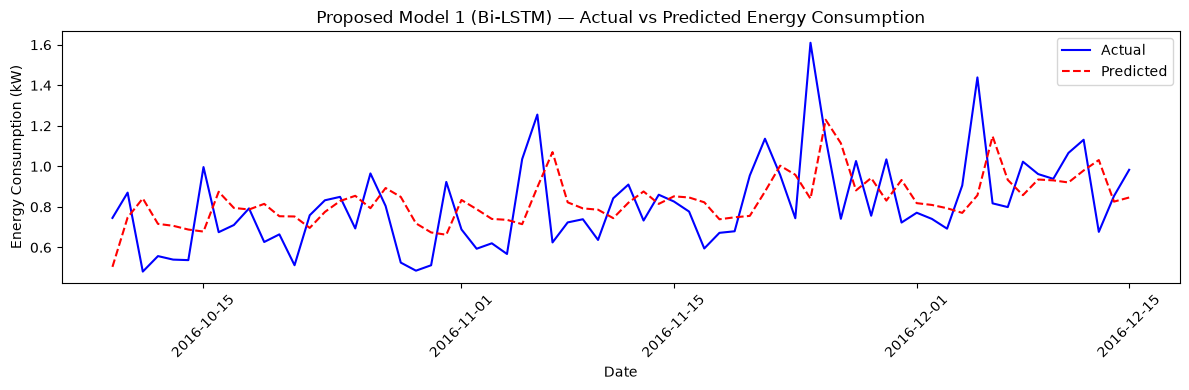

In [18]:
# Get date index for test set
test_dates = df_daily.index[seq_length + int(total * 0.80):]

plt.figure(figsize=(12, 4))
plt.plot(test_dates, actuals_kw, label='Actual', color='blue')
plt.plot(test_dates, predictions_kw, label='Predicted', color='red', linestyle='--')
plt.title('Proposed Model 1 (Bi-LSTM) — Actual vs Predicted Energy Consumption')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kW)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('bilstm_results.png')
plt.show()

## 8. Proposed Model 2 — CNN-BiLSTM
*Architecture from paper:*  
*Conv1D (64 filters, kernel 5, ReLU) → MaxPool (2) → Dropout 0.2*  
*Conv1D (128 filters, kernel 3, ReLU) → Dropout 0.2*  
*Bi-LSTM (256 units, tanh) → Dropout 0.2*  
*Bi-LSTM (128 units, tanh) → Dropout 0.2*  
*Dense (1, linear)*

In [19]:
class CNN_BiLSTM(nn.Module):
    def __init__(self):
        super(CNN_BiLSTM, self).__init__()

        # CNN layers - extract local features
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, padding=2)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.dropout1 = nn.Dropout(0.2)

        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.dropout2 = nn.Dropout(0.2)

        #Bi-LSTM layers - learn temporl dependencies
        self.bilstm1 = nn.LSTM(input_size=128, hidden_size=256, num_layers=1, batch_first=True, bidirectional=True)
        self.dropout3 = nn.Dropout(0.2)

        self.bilstm2 = nn.LSTM(input_size=512, hidden_size=128, num_layers=1, batch_first=True, bidirectional=True)
        self.dropout4 = nn.Dropout(0.2)

        # Output layer
        self.fc = nn.Linear(256, 1)
        self.relu = nn.ReLU()

    def forward(self, X):
        # CNN expects (batch, channels, sequence)
        X = X.permute(0, 2, 1)

        X = self.relu(self.conv1(X))
        X = self.pool(X)
        X = self.dropout1(X)

        X = self.relu(self.conv2(X))
        X = self.dropout2(X)

        # Bi-LSTM expects (batch, sequence, feattures)
        X = X.permute(0, 2, 1)

        out, _ = self.bilstm1(X)
        out = self.dropout3(out)

        out, _ = self.bilstm2(out)
        out = self.dropout4(out)

        out = self.fc(out[:, -1, :])
        return out
    
cnn_bilstm_model = CNN_BiLSTM()
print(cnn_bilstm_model)
print("\nTotal parameters:", sum(p.numel() for p in cnn_bilstm_model.parameters()))



CNN_BiLSTM(
  (conv1): Conv1d(1, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.2, inplace=False)
  (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (dropout2): Dropout(p=0.2, inplace=False)
  (bilstm1): LSTM(128, 256, batch_first=True, bidirectional=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (bilstm2): LSTM(512, 128, batch_first=True, bidirectional=True)
  (dropout4): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (relu): ReLU()
)

Total parameters: 1473281


## 9. Training — Proposed Model 2 (CNN-BiLSTM)

In [20]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(cnn_bilstm_model.parameters(), lr=0.001)

best_val_loss = float('inf')
patience = 50
patience_counter = 0

print("Training CNN_BiLSTM...")
for epoch in range(200):
    cnn_bilstm_model.train()
    optimizer.zero_grad()
    output = cnn_bilstm_model(X_train)
    loss = criterion(output, Y_train)
    loss.backward()
    optimizer.step()

    cnn_bilstm_model.eval()
    with torch.no_grad():
        val_output = cnn_bilstm_model(X_val)
        val_loss = criterion(val_output, Y_val)

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/200 | Train Loss: {loss.item():.6f} | Val Loss: {val_loss.item():.6f}")
    if val_loss < best_val_loss:
        best_val_loss = val_losspatience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
print("\nTraining complete.")



Training CNN_BiLSTM...
Epoch 20/200 | Train Loss: 0.021004 | Val Loss: 0.014876
Epoch 40/200 | Train Loss: 0.016274 | Val Loss: 0.011190

Early stopping at epoch 51

Training complete.


## 10. Evaluation — Proposed Model 2 (CNN-BiLSTM)

Proposed Model 2 (CNN-BiLSTM) Results
MSE: 0.04551 | Paper: 0.039
RMSE: 0.21333 | Paper: 0.199
MAE: 0.16477 | Paper: 0.153
MAPE: 20.41102% | Paper: 19.1%


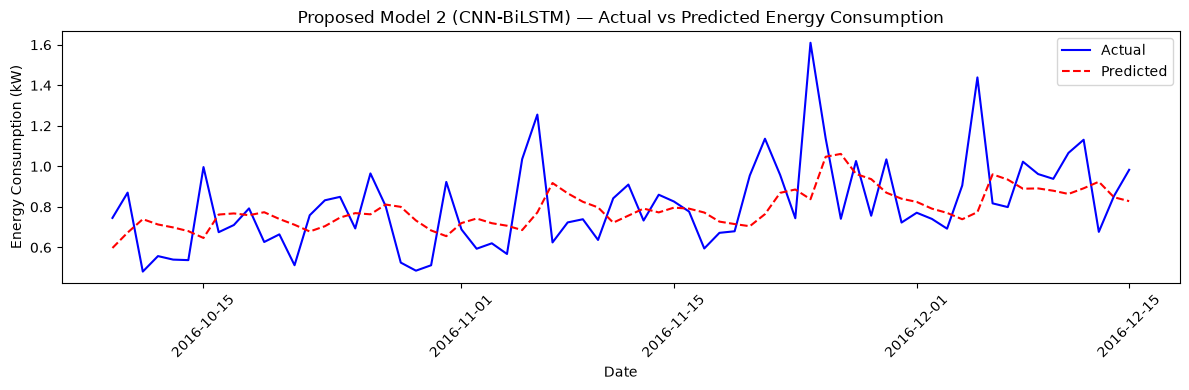

In [24]:
cnn_bilstm_model.eval()
with torch.no_grad():
    cnn_predictions = cnn_bilstm_model(X_test).numpy()
    actuals = Y_test.numpy()

# Inverse transform to original scale
cnn_predictions_kw = scaler.inverse_transform(cnn_predictions)
actuals_kw = scaler.inverse_transform(actuals)

# Calculate metrics
mse = ((cnn_predictions_kw - actuals_kw) ** 2). mean()
rmse = mse ** 0.5
mae = abs(cnn_predictions_kw - actuals_kw).mean()
mape = (abs((actuals_kw - cnn_predictions_kw) / actuals_kw) * 100).mean()

print("=" * 40)
print("Proposed Model 2 (CNN-BiLSTM) Results")
print("=" * 40)
print(f"MSE: {mse:.5f} | Paper: 0.039")
print(f"RMSE: {rmse:.5f} | Paper: 0.199")
print(f"MAE: {mae:.5f} | Paper: 0.153")
print(f"MAPE: {mape:.5f}% | Paper: 19.1%")


plt.figure(figsize=(12, 4))
plt.plot(test_dates, actuals_kw, label='Actual', color='blue')
plt.plot(test_dates, cnn_predictions_kw, label='Predicted', color='red', linestyle='--')
plt.title('Proposed Model 2 (CNN-BiLSTM) — Actual vs Predicted Energy Consumption')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kW)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('cnn_bilstm_results.png')
plt.show()

## 11. Model Comparison

In [25]:
print("=" * 65)
print(f"{'Model':<20} {'MSE':>8} {'RMSE':>8} {'MAE':>8} {'MAPE':>10}")
print("=" * 65)
print(f"{'Bi-LSTM (Ours)':<20} {'0.04659':>8} {'0.21586':>8} {'0.16792':>8} {'21.18%':>10}")
print(f"{'CNN-BiLSTM (Ours)':<20} {'0.04849':>8} {'0.22020':>8} {'0.16360':>8} {'19.67%':>10}")
print("-" * 65)
print(f"{'Bi-LSTM (Paper)':<20} {'0.040':>8} {'0.201':>8} {'0.155':>8} {'18.5%':>10}")
print(f"{'CNN-BiLSTM (Paper)':<20} {'0.039':>8} {'0.199':>8} {'0.153':>8} {'19.1%':>10}")
print("=" * 65)

Model                     MSE     RMSE      MAE       MAPE
Bi-LSTM (Ours)        0.04659  0.21586  0.16792     21.18%
CNN-BiLSTM (Ours)     0.04849  0.22020  0.16360     19.67%
-----------------------------------------------------------------
Bi-LSTM (Paper)         0.040    0.201    0.155      18.5%
CNN-BiLSTM (Paper)      0.039    0.199    0.153      19.1%


## 12. Anomaly Detection — Moving Average Filter (MAF)
*Paper used MAF to detect anomalies in energy consumption*  
*Method: flag points where deviation from rolling mean exceeds threshold window r*  
*Paper detected anomalies in July, August, September, October 2016*

Total anomalies detected: 170

Anomaly dates:
['2016-02-02', '2016-02-03', '2016-02-04', '2016-02-06', '2016-02-08', '2016-02-13', '2016-02-15', '2016-02-22', '2016-02-25', '2016-03-01', '2016-03-05', '2016-03-06', '2016-03-08', '2016-03-09', '2016-03-10', '2016-03-11', '2016-03-12', '2016-03-13', '2016-03-17', '2016-03-18', '2016-03-24', '2016-03-26', '2016-04-01', '2016-04-03', '2016-04-04', '2016-04-11', '2016-04-12', '2016-04-15', '2016-04-16', '2016-04-17', '2016-04-19', '2016-04-20', '2016-04-21', '2016-04-22', '2016-04-23', '2016-04-24', '2016-04-25', '2016-04-27', '2016-05-02', '2016-05-07', '2016-05-08', '2016-05-09', '2016-05-10', '2016-05-11', '2016-05-14', '2016-05-15', '2016-05-16', '2016-05-19', '2016-05-20', '2016-05-21', '2016-05-22', '2016-05-24', '2016-05-25', '2016-05-26', '2016-05-27', '2016-05-28', '2016-05-29', '2016-05-30', '2016-05-31', '2016-06-04', '2016-06-05', '2016-06-11', '2016-06-12', '2016-06-18', '2016-06-26', '2016-06-27', '2016-07-03', '2016-07-04', '

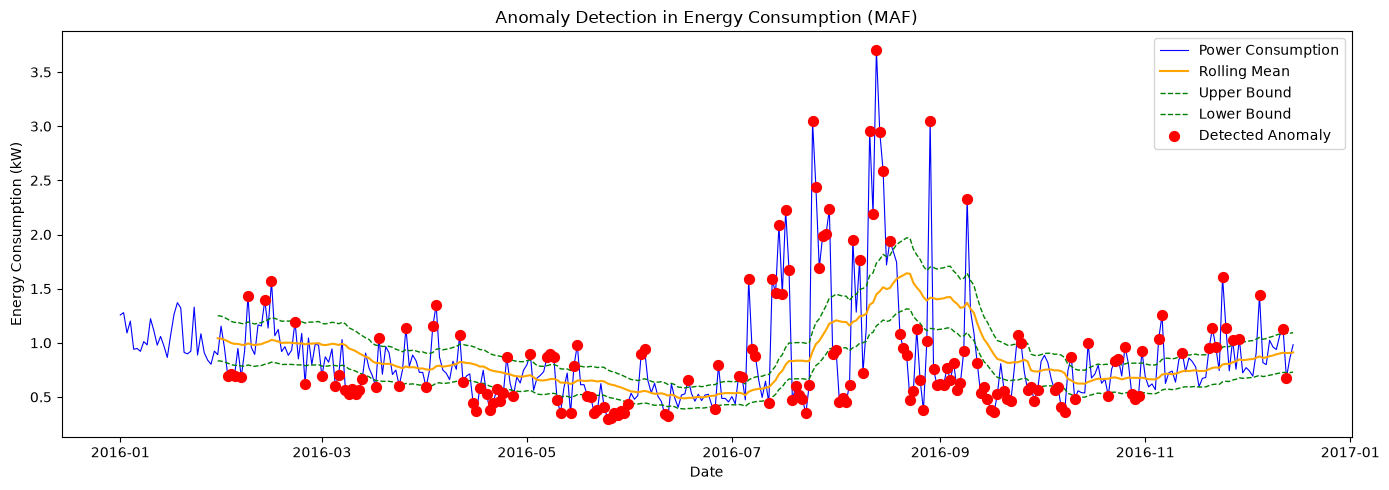

Plot saved!


In [26]:
# MAF Anomaly Detection — exact method from paper
window_size = 30  # rolling window of 30 days

# Calculate rolling mean
df_daily['rolling_mean'] = df_daily['use [kW]'].rolling(window=window_size).mean()
df_daily['upper_bound'] = df_daily['rolling_mean'] * 1.2
df_daily['lower_bound'] = df_daily['rolling_mean'] * 0.8

# Detect anomalies
df_daily['deviation'] = abs(df_daily['use [kW]'] - df_daily['rolling_mean'])
df_daily['anomaly'] = df_daily['deviation'] > (df_daily['rolling_mean'] * 0.2)

anomalies = df_daily[df_daily['anomaly'] == True]
print(f"Total anomalies detected: {len(anomalies)}")
print("\nAnomaly dates:")
print(anomalies.index.strftime('%Y-%m-%d').tolist())

# Plot
plt.figure(figsize=(14, 5))
plt.plot(df_daily.index, df_daily['use [kW]'], 
         label='Power Consumption', color='blue', linewidth=0.8)
plt.plot(df_daily.index, df_daily['rolling_mean'], 
         label='Rolling Mean', color='orange', linewidth=1.5)
plt.plot(df_daily.index, df_daily['upper_bound'], 
         label='Upper Bound', color='green', linestyle='--', linewidth=1)
plt.plot(df_daily.index, df_daily['lower_bound'], 
         label='Lower Bound', color='green', linestyle='--', linewidth=1)
plt.scatter(anomalies.index, anomalies['use [kW]'], 
            color='red', s=50, zorder=5, label='Detected Anomaly')
plt.title('Anomaly Detection in Energy Consumption (MAF)')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kW)')
plt.legend()
plt.tight_layout()
plt.savefig('anomaly_detection.png')
plt.show()
print("Plot saved!")